# 1. Imports

In [51]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
from tqdm import tqdm

# PyTorch (De motor die je wél hebt geïnstalleerd)
import torch
import torch.nn as nn
import torch.optim as optim 
from torch.utils.data import DataLoader, Dataset

# HuggingFace Transformers (Voor AST)
from transformers import ASTFeatureExtractor, ASTForAudioClassification

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report

# 2. Exploratory analysis

In [52]:
import pandas as pd

df = pd.read_csv("data/train.csv")

df.head()

,sampleID,class
0,S_00000,cat
1,S_00001,cat
2,S_00002,pig
3,S_00004,hen
4,S_00005,water_drops


In [53]:
df['class'].value_counts()

class
cat               32
pig               32
hen               32
water_drops       32
rain              32
dog               32
sheep             32
cow               32
chirping_birds    32
Name: count, dtype: int64

Alle classes zijn eerlijk verdeeld.

## 2.1 Kijken of bestanden effectief evenlang duren

In [54]:
import soundfile as sf
import os

for index, row in df.head().iterrows():
    bestandspad = f"data/audio/{row['sampleID']}.wav"
    
    if os.path.exists(bestandspad):
        info = sf.info(bestandspad)
        
        print(f"Bestand: {row['sampleID']} | Klasse: {row['class']}")
        print(f" - Lengte: {info.duration} seconden")
        print(f" - Sample rate: {info.samplerate} Hz")
        print(f" - Kanalen: {info.channels} (1 = mono, 2 = stereo)\n")

Bestand: S_00000 | Klasse: cat
 - Lengte: 5.0 seconden
 - Sample rate: 44100 Hz
 - Kanalen: 1 (1 = mono, 2 = stereo)

Bestand: S_00001 | Klasse: cat
 - Lengte: 5.0 seconden
 - Sample rate: 44100 Hz
 - Kanalen: 1 (1 = mono, 2 = stereo)

Bestand: S_00002 | Klasse: pig
 - Lengte: 5.0 seconden
 - Sample rate: 44100 Hz
 - Kanalen: 1 (1 = mono, 2 = stereo)

Bestand: S_00004 | Klasse: hen
 - Lengte: 5.0 seconden
 - Sample rate: 44100 Hz
 - Kanalen: 1 (1 = mono, 2 = stereo)

Bestand: S_00005 | Klasse: water_drops
 - Lengte: 5.0 seconden
 - Sample rate: 44100 Hz
 - Kanalen: 1 (1 = mono, 2 = stereo)



## 2.2 Kijken naar een wave format

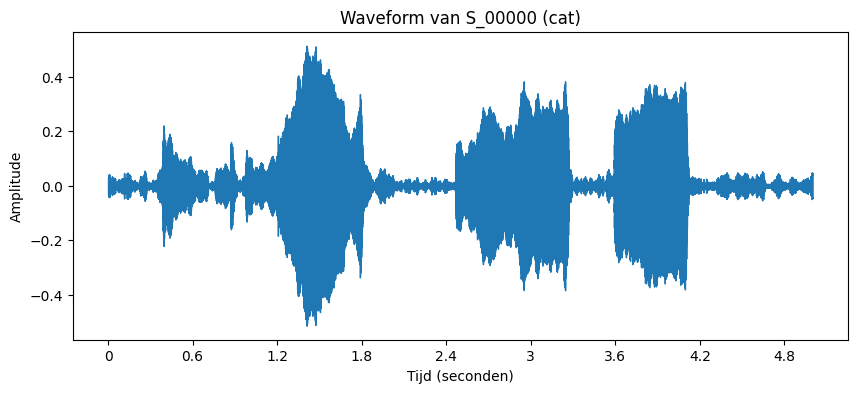

In [55]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

fp = f"data/audio/{df.iloc[0]['sampleID']}.wav"

sig, sr = librosa.load(fp, sr=None)

plt.figure(figsize=(10, 4))
librosa.display.waveshow(sig, sr=sr)
plt.title(f"Waveform van {df.iloc[0]['sampleID']} ({df.iloc[0]['class']})")
plt.xlabel("Tijd (seconden)")
plt.ylabel("Amplitude")
plt.show()

# 3. Train Test split

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['class'])

X = df['sampleID']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

In [57]:
df.head(20)

,sampleID,class,label
0,S_00000,cat,0
1,S_00001,cat,0
2,S_00002,pig,5
3,S_00004,hen,4
4,S_00005,water_drops,8
5,S_00006,pig,5
6,S_00007,rain,6
7,S_00008,dog,3
8,S_00009,water_drops,8
9,S_00010,cat,0


In [58]:
from transformers import ASTFeatureExtractor

feature_extractor = ASTFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

def extract_ast_features(ids):
    inputs = []
    for audio_id in tqdm(ids):
        path = f"data/audio/{audio_id}.wav"
        y, sr = librosa.load(path, sr=16000) 
        
        input_values = feature_extractor(y, sampling_rate=16000, return_tensors="pt")
        inputs.append(input_values.input_values.squeeze(0))
        
    return torch.stack(inputs)

X_train_ast = extract_ast_features(X_train)
X_test_ast = extract_ast_features(X_test)

100%|██████████| 58/58 [00:00<00:00, 202.49it/s]
